# DBSCAN Clustering with Circular Time Encoding
This notebook performs DBSCAN clustering using continuous features like Sea Surface Temperature (SST), Chlorophyll-a, and Sea Surface Level (SSL). It uses a circular encoding for the day of the year (`time_sin` and `time_cos`) to capture the continuous progression of the year. 
After clustering a sample, the result is analyzed via PCA and t-SNE, and finally applied to the average map of June 2018.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from datetime import datetime
import warnings
from tqdm.auto import tqdm

# Settings
plt.style.use('default')

In [2]:
# Load the data
try:
    with open(r'E:\satdata\Custom\yucatan_sst_chlor_cdomslope_ssl_bathy_2010-2019_v3.pkl', 'rb') as f:
        data = pickle.load(f)

    df = data['data']
    metadata = data['metadata']
    print("Data loaded successfully.")
except FileNotFoundError:
    print("Data file not found. Please check path.")

Data loaded successfully.


In [3]:
# Preprocess and extract features
# We need to flatten the grids into a tabular format, retaining spatial and temporal info.
records = []
grid_shape = None

print("Extracting features from grid data...")
for date, row in tqdm(df.iterrows(), total=len(df)):
    sst = row.get('sst')
    chlor = row.get('chlorophyll')
    ssl = row.get('ssl')
    
    if sst is None or chlor is None or ssl is None:
        continue
        
    sst_arr = np.array(sst, dtype=float)
    chlor_arr = np.array(chlor, dtype=float)
    ssl_arr = np.array(ssl, dtype=float)
    
    if grid_shape is None:
        grid_shape = sst_arr.shape
        
    sst_flat = sst_arr.flatten()
    chlor_flat = chlor_arr.flatten()
    ssl_flat = ssl_arr.flatten()
    
    # Identify valid pixels with no NaNs across all features
    valid_mask = ~np.isnan(sst_flat) & ~np.isnan(chlor_flat) & ~np.isnan(ssl_flat) & (chlor_flat > 0)
    valid_indices = np.where(valid_mask)[0]
    
    if len(valid_indices) == 0:
        continue
        
    # Circular encoding for day of year
    doy = date.timetuple().tm_yday
    time_sin = np.sin(2 * np.pi * doy / 365.25)
    time_cos = np.cos(2 * np.pi * doy / 365.25)
    
    for idx in valid_indices:
        records.append({
            'date': date,
            'pixel_idx': idx,
            'sst': sst_flat[idx],
            'chlor_log': np.log10(chlor_flat[idx]), # Apply log scale to chlorophyll
            'ssl': ssl_flat[idx],
            'time_sin': time_sin,
            'time_cos': time_cos
        })

df_pixels = pd.DataFrame(records)
print(f"Total valid pixel-days collected: {len(df_pixels):,}")

Extracting features from grid data...


  0%|          | 0/3662 [00:00<?, ?it/s]

Total valid pixel-days collected: 60,419,911


In [13]:
# Sample Data and Run DBSCAN
# To make DBSCAN computationally feasible, we sample the data.
sample_size = min(100000, len(df_pixels))
df_sample = df_pixels.sample(n=sample_size, random_state=42).copy()

features = ['sst', 'chlor_log', 'ssl', 'time_sin', 'time_cos']
X = df_sample[features].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Running DBSCAN on {len(X_scaled)} samples...")
# You may need to tune eps and min_samples based on the specific dataset distribution
dbscan = DBSCAN(eps=0.27, min_samples=40)
df_sample['cluster'] = dbscan.fit_predict(X_scaled)

print("Cluster assignments (Note: -1 represents noise points):")
print(df_sample['cluster'].value_counts())

Running DBSCAN on 100000 samples...
Cluster assignments (Note: -1 represents noise points):
cluster
 0    70555
-1    28425
 1      791
 2      128
 3       40
 5       38
 4       23
Name: count, dtype: int64


Running PCA on 10000 samples...
Running t-SNE on 10000 samples...


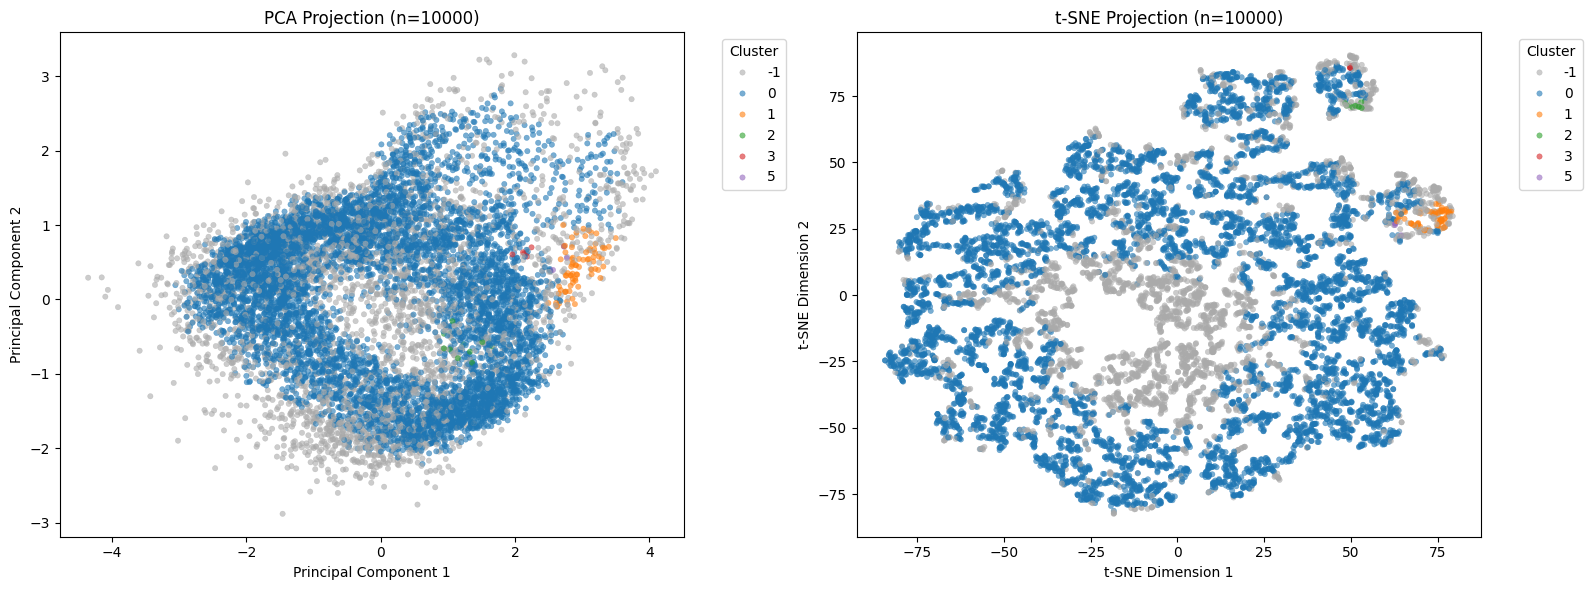

In [14]:
# PCA vs t-SNE Visualization on a Subsample
# Subsample for visualization to speed up t-SNE and PCA
viz_sample_size = min(1000, len(X_scaled))
indices = np.random.choice(len(X_scaled), viz_sample_size, replace=False)
X_viz_scaled = X_scaled[indices]
df_viz = df_sample.iloc[indices].copy()

print(f"Running PCA on {viz_sample_size} samples...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_viz_scaled)

print(f"Running t-SNE on {viz_sample_size} samples...")
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_viz_scaled)

df_viz['pca1'] = X_pca[:, 0]
df_viz['pca2'] = X_pca[:, 1]
df_viz['tsne1'] = X_tsne[:, 0]
df_viz['tsne2'] = X_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Define palette to map noise (-1) to grey if present
unique_clusters = sorted(df_viz['cluster'].unique())
palette = sns.color_palette("tab10", len(unique_clusters))
if -1 in unique_clusters:
    # Set the first color (index for -1 noise) to grey
    palette = ['#aaaaaa'] + sns.color_palette("tab10", len(unique_clusters)-1)

sns.scatterplot(
    data=df_viz, x='pca1', y='pca2', 
    hue='cluster', palette=palette, ax=ax1, s=15, alpha=0.6, edgecolor=None
)
ax1.set_title(f'PCA Projection (n={viz_sample_size})')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.scatterplot(
    data=df_viz, x='tsne1', y='tsne2', 
    hue='cluster', palette=palette, ax=ax2, s=15, alpha=0.6, edgecolor=None
)
ax2.set_title(f't-SNE Projection (n={viz_sample_size})')
ax2.set_xlabel('t-SNE Dimension 1')
ax2.set_ylabel('t-SNE Dimension 2')
ax2.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Applying Clusters to June 2018 Average Map...


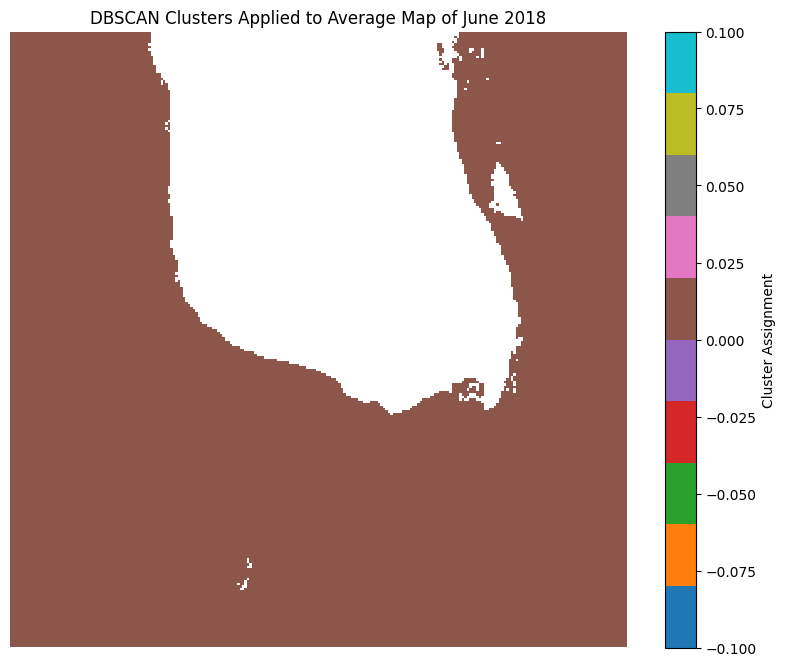

In [10]:
# Predict Map for June 2018
print("Applying Clusters to June 2018 Average Map...")

# Filter the main DataFrame for June 2018
mask_june2018 = (df.index.year == 2018) & (df.index.month == 6)
df_june2018 = df[mask_june2018]

# Compute spatial averages for June 2018
sst_grids = []
chlor_grids = []
ssl_grids = []

for _, row in df_june2018.iterrows():
    if row['sst'] is not None: sst_grids.append(row['sst'])
    if row['chlorophyll'] is not None: chlor_grids.append(row['chlorophyll'])
    if row['ssl'] is not None: ssl_grids.append(row['ssl'])

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    avg_sst = np.nanmean(np.array(sst_grids), axis=0)
    avg_chlor = np.nanmean(np.array(chlor_grids), axis=0)
    avg_ssl = np.nanmean(np.array(ssl_grids), axis=0)

# Build features for June 2018
# Using mid-June (Day 166) for time encoding
doy = 166
time_sin = np.sin(2 * np.pi * doy / 365.25)
time_cos = np.cos(2 * np.pi * doy / 365.25)

# Since DBSCAN doesn't naturally predict new points, 
# we train a K-Nearest Neighbors classifier on the DBSCAN core samples to propagate labels.
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

X_core = X_scaled[core_samples_mask]
y_core = dbscan.labels_[core_samples_mask]

if len(X_core) > 0:
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_core, y_core)
    
    map_clusters = np.full(grid_shape, np.nan)
    
    for i in range(grid_shape[0]):
        for j in range(grid_shape[1]):
            s = avg_sst[i, j]
            c = avg_chlor[i, j]
            sl = avg_ssl[i, j]
            
            if not np.isnan(s) and not np.isnan(c) and not np.isnan(sl) and c > 0:
                c_log = np.log10(c)
                pt = np.array([[s, c_log, sl, time_sin, time_cos]])
                pt_scaled = scaler.transform(pt)
                map_clusters[i, j] = knn.predict(pt_scaled)[0]

    plt.figure(figsize=(10, 8))
    # We use vmin and vmax based on the unique non-noise clusters 
    # and use the same palette order for consistency.
    plt.imshow(map_clusters, cmap='tab10', interpolation='nearest')
    plt.colorbar(label='Cluster Assignment')
    plt.title('DBSCAN Clusters Applied to Average Map of June 2018')
    plt.axis('off')
    plt.show()
else:
    print("DBSCAN found no core samples. Try adjusting eps and min_samples parameters.")